# School Closures

Using the functions previously defined in `CostCalculations.ipynb`, I will slightly edit my two classes (`ODEsClass` and `simAllAges`) - with an added variable `schoolClosure` that, when False, means that $\beta^{11}$ does not drop when the population enters lockdown (to represent the continued interaction of children with other children while in school). When True the model works as before, and all age groups experience the same drop in transmission. Under the first subheading, I plotted the number of susceptible/exposed/infected/etc. people and it is clear that in lockdown (when schools are open), the infected and exposed numbers for 0-19 year olds are not affected.

To be more realistic, I will add a cost to school closures. Sadique, Adams, and Edmunds (2008) suggest this would be from £0.2bn to £1.2bn, the majority of this due to parents taking time off work to care for their children. The long term effect of missed education is harder to quantify like this and so I have omitted it, as my model is short-term.

### Table of Contents

-[SEIHRVD model with school closure](#model_schoolclosure)  
  > •[Plotting model](#SEIHRVDplotted)    
  
-[Cost function](#costfct)  

-[Plotting net monetary loss](#netmoneyloss)  

-[Triangle plots - comparing schools open and closed](#triangleplots)  
  > •[Willingness to pay £20,000](#W=20k)  
  > •[Willingness to pay £50,000](#W=50k)  
  > •[Willingness to pay £100,000](#W=100k)  

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import json
from types import SimpleNamespace
import math
import mpltern
import matplotlib.colors as mcolors
import time

f = open("params.json", "r")
contents = f.read()
f.close()


params = json.loads(contents)

    
youngAgeGrp = params['0-19']
adultAgeGrp = params['20-64']
elderlyAgeGrp = params['65+']

allAgeGrpParams = (youngAgeGrp, adultAgeGrp, elderlyAgeGrp)

## School closure classes <a id = 'model_schoolclosure' ><a>

In [19]:
# Adding 'schoolClosure' , so  = True means schools are closed and everyone has the same drop in transmission, and = False means schools open and beta^{11} does not change in lockdown

class ODEsClass:
    
    def __init__(self, ageGrpParams, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days, schoolClosure):
        self.params = SimpleNamespace(**ageGrpParams)
        self.params.eta1 = eta
        self.params.eta2 = 0.8*eta
        self.schoolClosure = schoolClosure
        self.params.lockdown1Start = lockdown1Start
        self.params.lockdown1End = lockdown1End
        self.params.lockdown2Start = lockdown2Start
        self.params.lockdown2End = lockdown2End
        self.params.outbreak2Start = outbreak2Start
        self.params.days = days
        
        self.InitialVals = list(self.params.compartments.values()) # all 40 initial vals from modelParameters
        
    def betaFunc(self, time, var, ageGrp):
        beta = self.params.__dict__[var][ageGrp]
        
        if ((self.schoolClosure == False) and (ageGrp == 0)): # if schools are open, children-to-children transmission is unchanged by lockdown
            newBeta = beta 
        elif self.params.lockdown1Start < time <= self.params.lockdown1End:
            newBeta = (beta/self.params.compliance)*(1 + (self.params.compliance - 1)*np.exp(-(time - self.params.lockdown1Start)))
        elif self.params.lockdown2Start < time <= self.params.lockdown2End:
            newBeta = (beta/self.params.compliance)*(1 + (self.params.compliance - 1)*np.exp(-(time - self.params.lockdown2Start)))
        elif self.params.lockdown1End < time <= self.params.lockdown2Start:
            newBeta = beta + (beta*(1-self.params.compliance)/self.params.compliance)*np.exp(-self.params.easing*(time - self.params.lockdown1End))
        elif time > self.params.lockdown2End:
            newBeta = beta + (beta*(1-self.params.compliance)/self.params.compliance)*np.exp(-self.params.easing*(time - self.params.lockdown2End))
        else:
            newBeta = beta
        return newBeta
    

        # define all variables in a new local scope
    def defineVars(self, IVS, FOI1, FOI2, state):

        S_U = {0: self.params.omega1*IVS[30] - FOI1*IVS[0]/self.params.N,
               1: self.params.omega1*IVS[30]  - FOI1*IVS[0]/self.params.N - self.params.sigma*IVS[0],
               2: self.params.omega1*IVS[30] + self.params.omega2*IVS[32] - (FOI1+FOI2)*IVS[0]/self.params.N,
               3: self.params.omega1*IVS[30] + self.params.omega2*IVS[32] - (FOI1+FOI2)*IVS[0]/self.params.N - self.params.sigma*IVS[0] ,
              }[state]

        S1_V = {0: 0,
               1: self.params.sigma*(1-self.params.eta1)*IVS[0] + self.params.omega1*IVS[31] - FOI1*IVS[1]/self.params.N,
               2: 0,
               3: self.params.sigma*(1-self.params.eta1)*IVS[0] + self.params.omega1*IVS[31] + self.params.omega2*IVS[33] - (FOI1+FOI2)*IVS[1]/self.params.N,
              }[state]

        S1_VI = {0: 0,
               1: self.params.sigma*self.params.eta1*IVS[0],
               2: 0,
               3: self.params.sigma*self.params.eta1*IVS[0] - IVS[2],
               }[state]

        S2_V = {0: 0,
               1: 0,
               2: 0,
               3: (1-self.params.eta2)*IVS[2] + self.params.omega2*IVS[34] - FOI2*IVS[3]/self.params.N,
              }[state]

        S2_VI = {0: 0,
               1: 0,
               2: 0,
               3: self.params.eta2*IVS[2]
               }[state]

        E1_U = {0: FOI1*IVS[0]/self.params.N - self.params.epsilon1*IVS[5],
                1: FOI1*IVS[0]/self.params.N - self.params.epsilon1*IVS[5],
                2: FOI1*IVS[0]/self.params.N - self.params.epsilon1*IVS[5],
                3: FOI1*IVS[0]/self.params.N - self.params.epsilon1*IVS[5],
               }[state]

        E1_V = {0: 0,
                1: FOI1*IVS[1]/self.params.N -self.params.epsilon1*IVS[6],
                2: 0,
                3: FOI1*IVS[1]/self.params.N -self.params.epsilon1*IVS[6],
               }[state]

        E2_U = {0: 0,
               1: 0,
               2: FOI2*IVS[0]/self.params.N - self.params.epsilon2*IVS[7],
               3: FOI2*IVS[0]/self.params.N - self.params.epsilon2*IVS[7],
               }[state]


        E2_V = {0: 0,
                1: 0,
                2: 0,
                3: FOI2*IVS[1]/self.params.N -self.params.epsilon2*IVS[8],
               }[state]

        E2_VI = {0: 0,
                1: 0,
                2: 0,
                3: FOI2*IVS[3]/self.params.N -self.params.epsilon2*IVS[9],
                }[state]


        I1_SU = {0: self.params.epsilon1*self.params.d1*IVS[5] - self.params.gamma1prime*IVS[10],
                1: self.params.epsilon1*self.params.d1*IVS[5] - self.params.gamma1prime*IVS[10],
                2: self.params.epsilon1*self.params.d1*IVS[5] - self.params.gamma1prime*IVS[10],
                3: self.params.epsilon1*self.params.d1*IVS[5] - self.params.gamma1prime*IVS[10],
                }[state]

        I1_AU = {0: self.params.epsilon1*(1-self.params.d1)*IVS[5] - self.params.gamma1*IVS[11],
                1: self.params.epsilon1*(1-self.params.d1)*IVS[5] - self.params.gamma1*IVS[11],
                2: self.params.epsilon1*(1-self.params.d1)*IVS[5] - self.params.gamma1*IVS[11],
                3: self.params.epsilon1*(1-self.params.d1)*IVS[5] - self.params.gamma1*IVS[11],
                }[state]

        I1_RU = {0: self.params.gamma1prime*(1 - self.params.h1)*IVS[10] - self.params.delta1prime*IVS[12],
                1: self.params.gamma1prime*(1 - self.params.h1)*IVS[10] - self.params.delta1prime*IVS[12],
                2: self.params.gamma1prime*(1 - self.params.h1)*IVS[10] - self.params.delta1prime*IVS[12],
                3: self.params.gamma1prime*(1 - self.params.h1)*IVS[10] - self.params.delta1prime*IVS[12],
                }[state]

        I1_SV = {0: 0,
                1: self.params.epsilon1*self.params.d1*IVS[6] - self.params.gamma1prime*IVS[13],
                2: 0,
                3: self.params.epsilon1*self.params.d1*IVS[6] - self.params.gamma1prime*IVS[13],
                }[state]

        I1_AV = {0: 0,
                1: self.params.epsilon1*(1-self.params.d1)*IVS[6] - self.params.gamma1*IVS[14],
                2: 0,
                3: self.params.epsilon1*(1-self.params.d1)*IVS[6] - self.params.gamma1*IVS[14],
                }[state]

        I1_RV = {0: 0,
                1: self.params.gamma1prime*(1 - self.params.h1)*IVS[13] - self.params.delta1prime*IVS[15],
                2: 0,
                3: self.params.gamma1prime*(1 - self.params.h1)*IVS[13] - self.params.delta1prime*IVS[15],
                }[state]

        I2_SU = {0: 0,
                1: 0,
                2: self.params.epsilon2*self.params.d2*IVS[7] - self.params.gamma2prime*IVS[16],
                3: self.params.epsilon2*self.params.d2*IVS[7] - self.params.gamma2prime*IVS[16],
                }[state]

        I2_AU = {0: 0,
                1: 0,
                2: self.params.epsilon2*(1-self.params.d2)*IVS[7] - self.params.gamma2*IVS[17],
                3: self.params.epsilon2*(1-self.params.d2)*IVS[7] - self.params.gamma2*IVS[17],
                }[state]

        I2_RU = {0: 0,
                1: 0,
                2: self.params.gamma2prime*(1 - self.params.h2)*IVS[16] - self.params.delta2prime*IVS[18],
                3: self.params.gamma2prime*(1 - self.params.h2)*IVS[16] - self.params.delta2prime*IVS[18],
                }[state]

        I2_SV = {0: 0,
                1: 0,
                2: 0,
                3: self.params.epsilon2*self.params.d2*IVS[8] - self.params.gamma2prime*IVS[19],
                }[state]

        I2_AV = {0: 0,
                1: 0,
                2: 0,
                3: self.params.epsilon2*(1-self.params.d2)*IVS[8] - self.params.gamma2*IVS[20],
                }[state]

        I2_RV = {0: 0,
                1: 0,
                2: 0,
                3: self.params.gamma2prime*(1 - self.params.h2)*IVS[19] - self.params.delta2prime*IVS[21],
                }[state]

        I2_SVI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.epsilon2*self.params.d2*IVS[9] - self.params.gamma2prime*IVS[22],
                 }[state]

        I2_AVI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.epsilon2*(1-self.params.d2)*IVS[9] - self.params.gamma2*IVS[23],
                 }[state]

        I2_RVI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.gamma2prime*(1 - self.params.h2)*IVS[22] - self.params.delta2prime*IVS[24],
                }[state]

        H1_U = {0: self.params.gamma1prime*self.params.h1*IVS[10] - self.params.delta1*IVS[25],
                1: self.params.gamma1prime*self.params.h1*IVS[10] - self.params.delta1*IVS[25],
                2: self.params.gamma1prime*self.params.h1*IVS[10] - self.params.delta1*IVS[25],
                3: self.params.gamma1prime*self.params.h1*IVS[10] - self.params.delta1*IVS[25],
               }[state]

        H1_V = {0: 0,
                1: self.params.gamma1prime*self.params.h1*IVS[13] - self.params.delta1*IVS[26],
                2: 0,
                3: self.params.gamma1prime*self.params.h1*IVS[13] - self.params.delta1*IVS[26],
               }[state]

        H2_U = {0: 0,
                1: 0,
                2: self.params.gamma2prime*self.params.h2*IVS[16] - self.params.delta2*IVS[27],
                3: self.params.gamma2prime*self.params.h2*IVS[16] - self.params.delta2*IVS[27],
               }[state]

        H2_V = {0: 0,
                1: 0,
                2: 0,
                3: self.params.gamma2prime*self.params.h2*IVS[19] - self.params.delta2*IVS[28],
               }[state]

        H2_VI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.gamma2prime*self.params.h2*IVS[22] - self.params.delta2*IVS[29],
                }[state]

        R1_U = {0: self.params.delta1*(1-self.params.k1)*IVS[25] + self.params.delta1prime*IVS[12] + self.params.gamma1*IVS[11] - self.params.omega1*IVS[30],
                1: self.params.delta1*(1-self.params.k1)*IVS[25] + self.params.delta1prime*IVS[12] + self.params.gamma1*IVS[11] - self.params.omega1*IVS[30],
                2: self.params.delta1*(1-self.params.k1)*IVS[25] + self.params.delta1prime*IVS[12] + self.params.gamma1*IVS[11] - self.params.omega1*IVS[30],
                3: self.params.delta1*(1-self.params.k1)*IVS[25] + self.params.delta1prime*IVS[12] + self.params.gamma1*IVS[11] - self.params.omega1*IVS[30],
               }[state]

        R1_V = {0: 0,
                1: self.params.delta1*(1-self.params.k1)*IVS[26] + self.params.delta1prime*IVS[15] + self.params.gamma1*IVS[14] - self.params.omega1*IVS[31],
                2: 0,
                3: self.params.delta1*(1-self.params.k1)*IVS[26] + self.params.delta1prime*IVS[15] + self.params.gamma1*IVS[14] - self.params.omega1*IVS[31],
               }[state]

        R2_U = {0: 0,
                1: 0,
                2: self.params.delta2*(1-self.params.k2)*IVS[27] + self.params.delta2prime*IVS[18] + self.params.gamma2*IVS[17] - self.params.omega2*IVS[32],
                3: self.params.delta2*(1-self.params.k2)*IVS[27] + self.params.delta2prime*IVS[18] + self.params.gamma2*IVS[17] - self.params.omega2*IVS[32],
               }[state]

        R2_V = {0: 0,
                1: 0,
                2: 0,
                3: self.params.delta2*(1-self.params.k2)*IVS[28] + self.params.delta2prime*IVS[21] + self.params.gamma2*IVS[20] - self.params.omega2*IVS[33],
               }[state]

        R2_VI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.delta2*(1-self.params.k2)*IVS[29] + self.params.delta2prime*IVS[24] + self.params.gamma2*IVS[23] - self.params.omega2*IVS[34],
                }[state]

        D1_U = {0: self.params.delta1*self.params.k1*IVS[25],
                1: self.params.delta1*self.params.k1*IVS[25],
                2: self.params.delta1*self.params.k1*IVS[25],
                3: self.params.delta1*self.params.k1*IVS[25],
               }[state]

        D1_V = {0: 0,
                1: self.params.delta1*self.params.k1*IVS[26],
                2: 0,
                3: self.params.delta1*self.params.k1*IVS[26],
               }[state]

        D2_U = {0: 0,
                1: 0,
                2: self.params.delta2*self.params.k2*IVS[27],
                3: self.params.delta2*self.params.k2*IVS[27],
               }[state]

        D2_V = {0: 0,
                1: 0,
                2: 0,
                3: self.params.delta2*self.params.k2*IVS[28],
               }[state]

        D2_VI = {0: 0,
                1: 0,
                2: 0,
                3: self.params.delta2*self.params.k2*IVS[29],
                }[state]
        
        Y = [S_U, S1_V, S1_VI, S2_V, S2_VI, E1_U, E1_V, E2_U, E2_V, E2_VI,I1_SU, I1_AU, I1_RU, I1_SV, I1_AV, I1_RV,I2_SU, I2_AU, I2_RU, I2_SV, I2_AV, I2_RV, I2_SVI, I2_AVI, I2_RVI,H1_U, H1_V, H2_U, H2_V, H2_VI,R1_U, R1_V, R2_U, R2_V, R2_VI,D1_U, D1_V, D2_U, D2_V, D2_VI]

        return Y 

In [20]:
class simAllAges:

    def __init__(self, allAgeGrpParams, eta, vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days, schoolClosure):
        
        youngAgeGrp, adultAgeGrp, elderlyAgeGrp = allAgeGrpParams

        self.youngSim = ODEsClass(youngAgeGrp, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days, schoolClosure)
        self.adultSim = ODEsClass(adultAgeGrp, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days, schoolClosure = True)
        self.elderlySim = ODEsClass(elderlyAgeGrp, eta, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days, schoolClosure = True)
        
        self.outputs = []
        
        self.events = {
            'elderlyVaccStart': None,
            'adultVaccStart': None,
            'youngVaccStart': None,
            'outbreak2Start': None,
            'simulationEnd': None
        }
        
        
        self.ageGroups = [self.youngSim, self.adultSim, self.elderlySim]
        self.days = days
        self.outbreak2Start = outbreak2Start
        self.vaccineStart = vaccineStart

    def SEIHRVDmodel(self, time, IVS , state):  
        
        IVSlength = len(IVS)
        
        
        IVSyoung = IVS[0 : int(IVSlength/3)]
        IVSadult = IVS[int(IVSlength/3) : int(2 * IVSlength / 3)]
        IVSelderly = IVS[int(2 * IVSlength / 3) : IVSlength]
        
        ageIVS = [IVSyoung, IVSadult, IVSelderly]
        
        diffeqs = []
        
        for j, age in enumerate(self.ageGroups):
            FOI1 = 0
            FOI2 = 0
            for i in range(3):
                b1 = age.betaFunc(time, 'beta1', i)
                b2 = age.betaFunc(time, 'beta2', i)
                FOI1 += b1*(age.params.tau1*(ageIVS[i][11] + ageIVS[i][14]) + ageIVS[i][10] + ageIVS[i][12] + ageIVS[i][13] + ageIVS[i][15] + age.params.rho1*(ageIVS[i][25] + ageIVS[i][26]))
                FOI2 += b2*(age.params.tau2*(ageIVS[i][17] + ageIVS[i][20] + ageIVS[i][23]) + ageIVS[i][16] + ageIVS[i][18] + ageIVS[i][19] + ageIVS[i][21] + ageIVS[i][22] + ageIVS[i][24] + age.params.rho2*(ageIVS[i][27] + ageIVS[i][28] + ageIVS[i][29]))

            
            diffeqs.append(age.defineVars(ageIVS[j], FOI1, FOI2, int(state[j])))
            
            
        return list(np.array(diffeqs).ravel())
    
    
    def ODEsolver(self):
            
        ageInitialValues = []
        for age in self.ageGroups:
            ageInitialValues.append(age.InitialVals)

        def elderlyVaccStart(t,y, state):
            return (t - self.vaccineStart)
        
        elderlyVaccStart.terminal = True 
        elderlyVaccStart.direction = 1
        elderlyVaccStart.name = "elderlyVaccine"
     
        def adultVaccStart(t, y, state):
            totalElderlyVaccinated = y[81] + y[82] + y[83] + y[84] + y[86] + y[88] + y[89] + y[93] + y[94] + y[95] + y[99] + y[100] + y[101] + y[102] + y[103] + y[104] + y[106] + y[108] + y[109] + y[111] + y[113] + y[114] + y[116] + y[118] + y[119]
            totalElderlyPop = self.elderlySim.params.N
            targetVaccinated = 0.4 * totalElderlyPop 
            
            return(totalElderlyVaccinated - targetVaccinated) 
        
        adultVaccStart.terminal = True 
        adultVaccStart.direction = 1
        adultVaccStart.name = "adultVaccine"
        
        def youngVaccStart(t, y, state):
            totalAdultsVaccinated = y[41] + y[42] + y[43] + y[44] + y[46] + y[48] + y[49] + y[53] + y[54] + y[55] + y[59] + y[60] + y[61] + y[62] + y[63] + y[64] + y[66] + y[68] + y[69] + y[71] + y[73] + y[74] + y[76] + y[78] + y[79]
            totalAdultPop = self.adultSim.params.N
            targetVaccinated = 0.4 * totalAdultPop 
            
            return(totalAdultsVaccinated - targetVaccinated)
        
        youngVaccStart.terminal = True 
        youngVaccStart.direction = 1
        youngVaccStart.name = "youngVaccine"
        
        def outbreak2Starting(t,y, state):
            return (t - self.outbreak2Start) 
        
        outbreak2Starting.terminal = True  
        outbreak2Starting.direction = 1
        outbreak2Starting.name = "outbreak2"
    
        valuesArray = []
        timeAtLastEvent = 0
        currentIVS = list(np.array(ageInitialValues).ravel())
        
        elderlyVaccineBit = 0b0
        adultVaccineBit = 0b0
        youngVaccineBit = 0b0
        outbreak2Bit = 0b0
        
        state = '000' 
        
        activeEvents = [elderlyVaccStart, adultVaccStart, youngVaccStart, outbreak2Starting]
        while timeAtLastEvent < self.days:
            sol = spi.solve_ivp(
                self.SEIHRVDmodel, 
                (timeAtLastEvent, self.days), 
                currentIVS, 
                t_eval = np.arange(timeAtLastEvent, self.days,1),
                events = activeEvents,
                args = (state,) 
            )
            
            valuesArray.append(sol.y.T[1:])
            timeAtLastEvent = sol.t[-1]
            currentIVS = sol.y.T[-1]
            
            for i, eventName in enumerate(sol.t_events):
                if eventName.size > 0: 
                    event = activeEvents[i].name
                    activeEvents.pop(i)
                    
                    if event == "elderlyVaccine":
                        self.events['elderlyVaccStart'] = sol.t_events[i][0]
                        elderlyVaccineBit = 0b1
                    if event == "adultVaccine":
                        self.events['adultVaccStart'] = sol.t_events[i][0]
                        adultVaccineBit = 0b1
                    if event == "youngVaccine":
                        self.events['youngVaccStart'] = sol.t_events[i][0]
                        youngVaccineBit = 0b1
                    if event == "outbreak2":
                        self.events['outbreak2Start'] = sol.t_events[i][0]
                        outbreak2Bit = 0b1
                        
                        currentIVS[7] += 100
                        currentIVS[16] += 100
                        currentIVS[17] += 100
                        currentIVS[47] += 100
                        currentIVS[56] += 100
                        currentIVS[57] += 100
                        currentIVS[87] += 100
                        currentIVS[96] += 100
                        currentIVS[97] += 100
                        
            
            youngState = int( (outbreak2Bit<<1) | (youngVaccineBit) )
            adultState = int( (outbreak2Bit<<1) | (adultVaccineBit) )
            elderlyState = int( (outbreak2Bit<<1) | (elderlyVaccineBit) )
        
            state = str(youngState) + str(adultState) + str(elderlyState)
            if sol.status == 0: break
        
        valuesYoung = []
        valuesAdult = []
        valuesElderly = []
        
        for v in valuesArray:
            valueLength = len(v[0])
            for l in v:
                valuesYoung.append(l[0 : int(valueLength / 3)])
                valuesAdult.append(l[int(valueLength / 3) : int(2 * valueLength / 3)])
                valuesElderly.append(l[int(2 * valueLength / 3) : valueLength])

        
        total_values = [ valuesYoung , valuesAdult, valuesElderly]

        def totalAdderConsec(j, lower, upper):
            nonlocal total_values
            totalArray = []
            for i in range(len(total_values[j])): #iterate over every day
                total = 0
                for l in range(upper - lower + 1):
                    index = lower + l
                    total += total_values[j][i][index]
                totalArray.append(total)
                
            return totalArray
        
        def totalAdderIndices(j, indices):
            nonlocal total_values
            totalArray = []
            for i in range(len(total_values[j])):
                total = 0
                for l in indices:
                    total += total_values[j][i][l]
                totalArray.append(total)
                
            return totalArray
        
        self.outputs = []
        
        for i, age in enumerate(self.ageGroups):
        
            total_susceptible1 = totalAdderConsec(i, 0, 2)
            total_susceptible2 = totalAdderConsec(i, 3, 4)
            total_exposed1 = totalAdderConsec(i, 5, 6)
            total_exposed2 = totalAdderConsec(i, 7,9)
            total_infected1 = totalAdderConsec(i, 10, 15)
            total_infected2 = totalAdderConsec(i, 16, 24)
            total_hospitalised1 = totalAdderConsec(i, 25, 26)
            total_hospitalised2 = totalAdderConsec(i, 27, 29)
            total_recovered1 = totalAdderConsec(i, 30, 31)
            total_recovered2 = totalAdderConsec(i, 32, 34)
            total_dead1 = totalAdderConsec(i, 35, 36)
            total_dead2 = totalAdderConsec(i, 37, 39)
            total_vaccinated = totalAdderIndices(i, [1,2,3,4,6,8,9,13,14,15,19,20,21,22,23,24,26,28,29,31,33,34,36,38,39])
            self.totals = [total_susceptible1, total_susceptible2, total_exposed1, total_exposed2, total_infected1, total_infected2, total_hospitalised1, total_hospitalised2, total_recovered1, total_recovered2, total_dead1, total_dead2, total_vaccinated]
            self.vaccinated_immune = totalAdderIndices(i, [2,4,9,22,23,24,29,34,39])
            
            total_infectiousS1 = totalAdderIndices(i, [10, 13])
            dailyHosp1 = [age.params.gamma1prime*age.params.h1*(tis1) for tis1 in total_infectiousS1]
            
            total_infectiousS2 = totalAdderIndices(i, [16, 19, 22])
            dailyHosp2 = [age.params.gamma2prime*age.params.h2*(tis2) for tis2 in total_infectiousS2]
            
            self.dailyHosp = [dailyHosp1, dailyHosp2]
            
            self.outputs.append([self.totals, self.vaccinated_immune, self.dailyHosp])
        
        return(self.outputs)
    
    
    def outbreakEndResults(self, age):
        
        if len(self.outputs) == 0: 
            print('run sim first!')
            return
        
        self.totalHospitalised = math.ceil(sum(self.outputs[age][2][0] + self.outputs[age][2][1] ))
        self.totalDead = math.ceil(self.outputs[age][0][10][-1] + self.outputs[age][0][11][-1])
        self.totalVaccinated = math.ceil(self.outputs[age][0][12][-1])
        
        return(self.totalHospitalised, self.totalDead, self.totalVaccinated)
    
    def getVaccineDays(self):
        
        vaccDaysArray = []
        for ageGrp in ['elderlyVaccStart', 'adultVaccStart', 'youngVaccStart']:
            if self.events[ageGrp] is None:
                vaccDaysArray.append(0)
            else:
                vaccinationStart = math.floor(self.events[ageGrp])
                vaccDaysArray.append(vaccinationStart)
        
        return(vaccDaysArray)
        
    def printEndResults(self, age):
        results = self.outbreakEndResults(age)
        print("Over the course of the outbreak,", results[0], "people were hospitalised.")
        print("Over the course of the outbreak,", results[1], "people died.")
        print(results[2], "people have been vaccinated -", math.ceil(self.outputs[age][1][-1]), "successfully.") 

### Plotting S,E,I,H,R,V,D <a  id = 'SEIHRVDplotted' ><a>

In [53]:
eta = 0.9
days = 365
lockdown1Start = 40
lockdown1End = 40 + 6*7
lockdown2Start = days+1
lockdown2End = days+1
outbreak2Start = 150
vaccineStart = 70
schoolClosure = False # schools open


simulation = simAllAges(allAgeGrpParams, eta, vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days, schoolClosure)
Y, A, E = simulation.ODEsolver()
totalsY, vaccImmuneY, hospitalisationsY = Y
totalsA, vaccImmuneA, hospitalisationsA = A
totalsE, vaccImmuneE, hospitalisationsE = E

elderlyVaccStart, adultVaccStart, youngVaccStart = simulation.getVaccineDays()

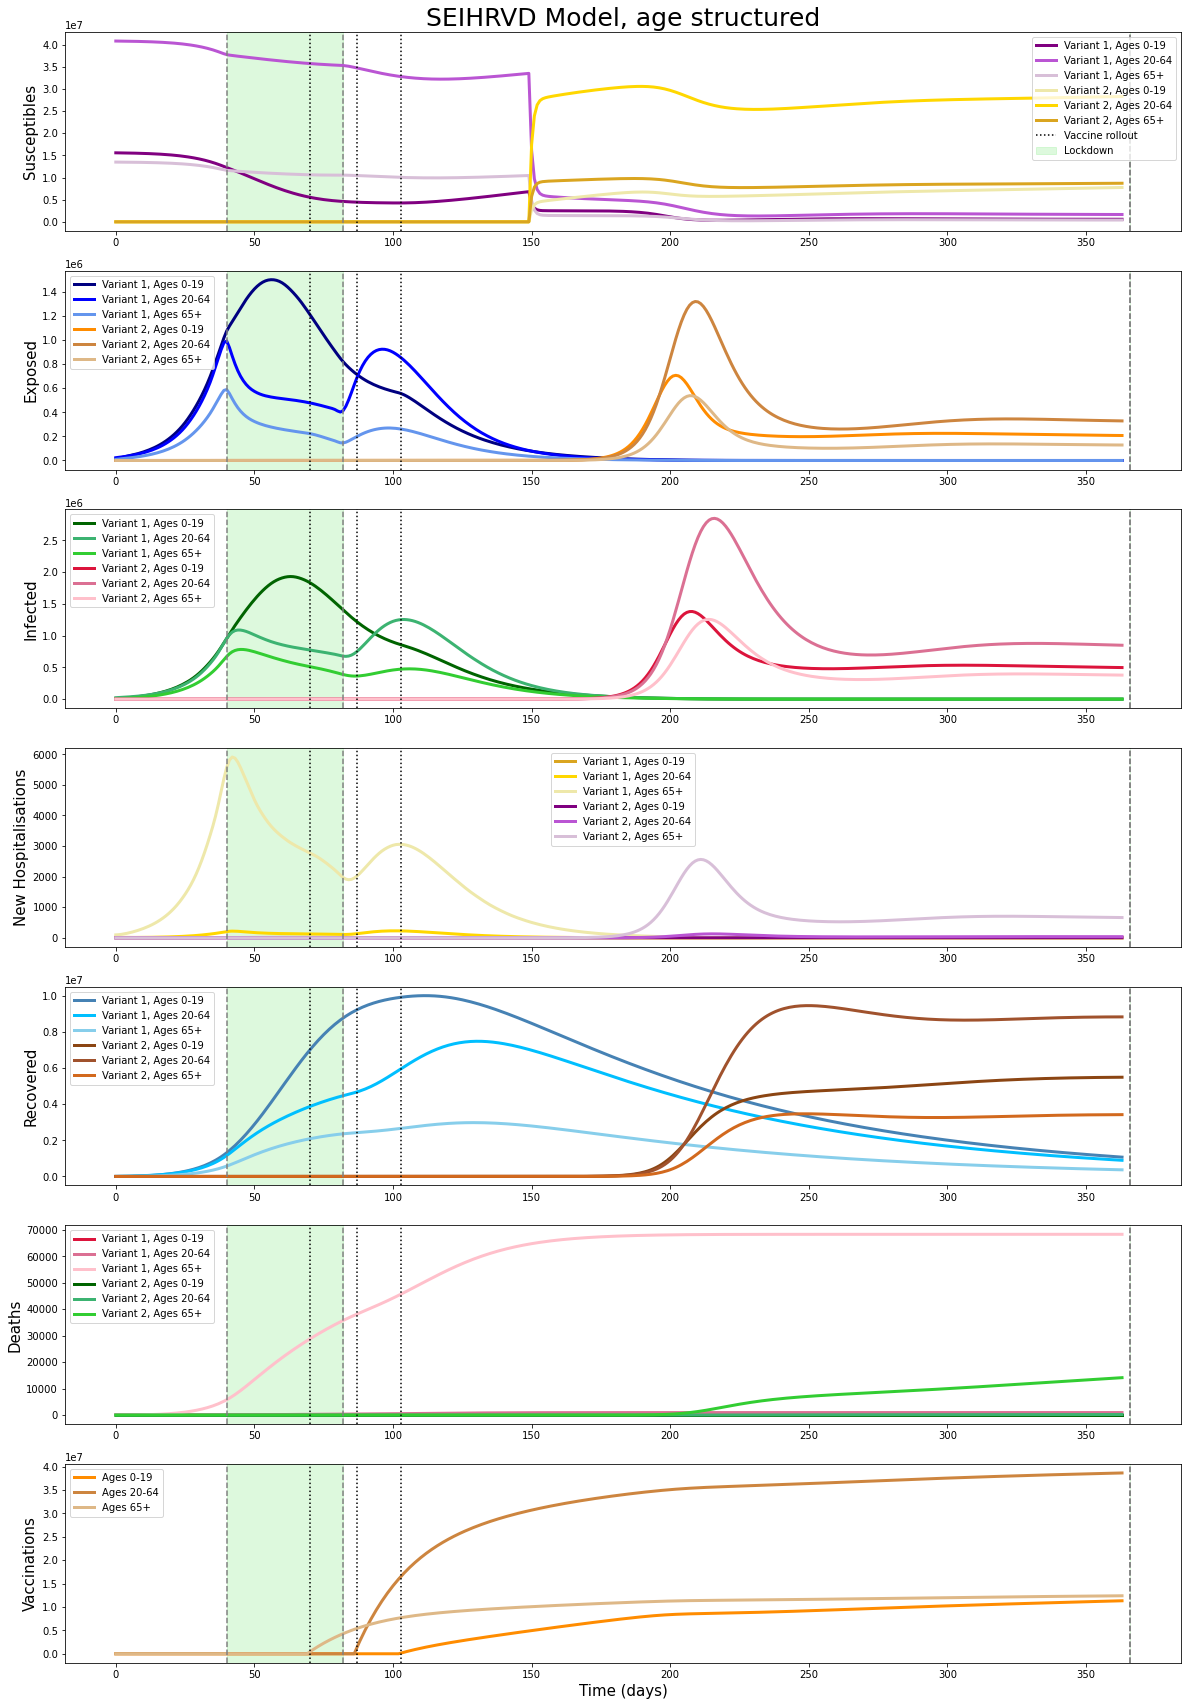

In [54]:
# PLOTTING:
plt.figure(figsize=(20, 30))

plt.subplot(711) # SUSCEPTIBLES
plt.plot(totalsY[0], 'purple', linewidth = 3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[0], 'mediumorchid', linewidth = 3, label = 'Variant 1, Ages 20-64')
plt.plot(totalsE[0], 'thistle', linewidth = 3, label = 'Variant 1, Ages 65+')
plt.plot(totalsY[1], 'palegoldenrod', linewidth=3, label = 'Variant 2, Ages 0-19')
plt.plot(totalsA[1], 'gold', linewidth = 3, label = 'Variant 2, Ages 20-64')
plt.plot(totalsE[1], 'goldenrod', linewidth = 3, label = 'Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted', label = 'Vaccine rollout')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen', label = 'Lockdown')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.title('SEIHRVD Model, age structured', fontsize=25)
plt.legend(loc=0)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(712) # EXPOSED
plt.plot(totalsY[2], 'navy', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[2], 'blue', linewidth = 3, label='Variant 1, Ages 20-64')
plt.plot(totalsE[2], 'cornflowerblue', linewidth = 3, label='Variant 1, Ages 65+')
plt.plot(totalsY[3], 'darkorange', linewidth = 3, label='Variant 2, Ages 0-19')
plt.plot(totalsA[3], 'peru', linewidth = 3, label='Variant 2, Ages 20-64')
plt.plot(totalsE[3], 'burlywood', linewidth = 3, label='Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Exposed', fontsize=15)

plt.subplot(713) # INFECTIOUS
plt.plot(totalsY[4], 'darkgreen', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[4], 'mediumseagreen', linewidth = 3, label = 'Variant 1, Ages 20-64')
plt.plot(totalsE[4], 'limegreen', linewidth = 3, label = 'Variant 1, Ages 65+')
plt.plot(totalsY[5], 'crimson', linewidth=3, label = 'Variant 2, Ages 0-19')
plt.plot(totalsA[5], 'palevioletred', linewidth = 3, label='Variant 2, Ages 20-64')
plt.plot(totalsE[5], 'pink', linewidth = 3, label='Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(714) #HOSPITALISED
plt.plot(hospitalisationsY[0], 'goldenrod', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(hospitalisationsA[0], 'gold', linewidth = 3, label = 'Variant 1, Ages 20-64')
plt.plot(hospitalisationsE[0], 'palegoldenrod', linewidth = 3, label = 'Variant 1, Ages 65+')
plt.plot(hospitalisationsY[1], 'purple', linewidth = 3, label = 'Variant 2, Ages 0-19')
plt.plot(hospitalisationsA[1], 'mediumorchid', linewidth = 3, label = 'Variant 2, Ages 20-64')
plt.plot(hospitalisationsE[1], 'thistle', linewidth = 3, label = 'Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('New Hospitalisations', fontsize=15)

plt.subplot(715) # RECOVERED
plt.plot(totalsY[8], 'steelblue', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[8], 'deepskyblue', linewidth = 3, label = 'Variant 1, Ages 20-64')
plt.plot(totalsE[8], 'skyblue', linewidth = 3, label = 'Variant 1, Ages 65+')
plt.plot(totalsY[9], 'saddlebrown', linewidth=3, label = 'Variant 2, Ages 0-19')
plt.plot(totalsA[9], 'sienna', linewidth = 3, label = 'Variant 2, Ages 20-64')
plt.plot(totalsE[9], 'chocolate', linewidth = 3, label = 'Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle = 'dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Recovered', fontsize=15)

plt.subplot(716) # DEAD
plt.plot(totalsY[10], 'crimson', linewidth=3, label = 'Variant 1, Ages 0-19')
plt.plot(totalsA[10], 'palevioletred', linewidth = 3, label='Variant 1, Ages 20-64')
plt.plot(totalsE[10], 'pink', linewidth = 3, label='Variant 1, Ages 65+')
plt.plot(totalsY[11], 'darkgreen', linewidth=3, label = 'Variant 2, Ages 0-19')
plt.plot(totalsA[11], 'mediumseagreen', linewidth = 3, label = 'Variant 2, Ages 20-64')
plt.plot(totalsE[11], 'limegreen', linewidth = 3, label = 'Variant 2, Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.ylabel('Deaths', fontsize=15)

plt.subplot(717) # VACCINATED
plt.plot(totalsY[12], 'darkorange', linewidth = 3, label='Ages 0-19')
plt.plot(totalsA[12], 'peru', linewidth = 3, label='Ages 20-64')
plt.plot(totalsE[12], 'burlywood', linewidth = 3, label='Ages 65+')
plt.axvline(elderlyVaccStart, color = 'black', linestyle='dotted')
plt.axvline(adultVaccStart, color = 'black', linestyle='dotted')
plt.axvline(youngVaccStart, color = 'black', linestyle='dotted')
plt.axvline(lockdown1Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown1End, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2Start, color = 'grey', linestyle='dashed')
plt.axvline(lockdown2End, color = 'grey', linestyle='dashed')
plt.axvspan(xmin=lockdown1Start, xmax=lockdown1End, alpha = 0.3, color = 'lightgreen')
plt.axvspan(xmin=lockdown2Start, xmax=lockdown2End, alpha = 0.3, color = 'lightgreen')
plt.legend(loc=0)
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Vaccinations', fontsize = 15)

plt.show()

## Cost Functions, adding GDP loss for school closure  <a id = 'costfct' ><a>

In [59]:
def QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days, schoolClosure):
    
    totalCost = 0
    totalQALY = []
    
    for i in range(len(efficaciesArray)):
        
        simulation = simAllAges(allAgeGrpParams, efficaciesArray[i], vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days, schoolClosure)
        simulation.ODEsolver( )
        hospY, deadY, vaccY = simulation.outbreakEndResults(0)
        hospA, deadA, vaccA = simulation.outbreakEndResults(1)
        hospE, deadE, vaccE = simulation.outbreakEndResults(2)

        fatalQALY = (23.5*deadY + 17.6*deadA + 5.3*deadE)
        hospQALY = 10/365 * (0.948*hospY + 0.881*hospA + 0.738*hospE)

        totalQALY.append(fatalQALY + hospQALY)
     
    # GDP does not change with efficacy so we can do this outside the for loop:
    monthlyGDPnoLD = 103.6397
    monthlyGDPinLD = 103.6397 - 50.2415*0.5 + 116.9759*(0.5**2) - 90.7837*(0.5**4)
    dailyGDPloss = (monthlyGDPnoLD*(10**9) - monthlyGDPinLD*(10**9))/30
    
    if schoolClosure==True:
        totalGDPloss = (dailyGDPloss+ 200000000)*((lockdown1End - lockdown1Start) + (lockdown2End - lockdown2Start)) # if schools closed add 0.2bn GDP loss daily
    else:
        totalGDPloss = dailyGDPloss*((lockdown1End - lockdown1Start) + (lockdown2End - lockdown2Start))
    
    return(totalQALY, totalGDPloss)

# Dependent on willingness to pay - gives the overall net monetary loss
def totalCost(W, totalQALY, totalGDPloss, weights):
    totalCost=0
    for i in range(len(weights)):
        netMonetaryLoss = W*(totalQALY[i]) + totalGDPloss
    
        totalCost += weights[i] * netMonetaryLoss
    return(totalCost)

## Plotting net monetary loss <a id = "netmoneyloss" ></a>

In [28]:
def costsOverLockdowns(allAgeGrpParams, efficaciesArray, weights, vaccineStart, lockdown1Start, outbreak2Start, days, wks, schoolClosure):
    costArray1_LD1 = []
    costArray2_LD1 = []
    costArray3_LD1 = []
    
    for i in wks:
        QALYloss, GDPloss = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+i*7, 0, 0, outbreak2Start, days, schoolClosure)
        
        costArray1_LD1.append(totalCost(20000, QALYloss, GDPloss, weights))
        costArray2_LD1.append(totalCost(50000, QALYloss, GDPloss, weights))
        costArray3_LD1.append(totalCost(100000, QALYloss, GDPloss, weights))
        
    costArrayLD1 = [costArray1_LD1, costArray2_LD1, costArray3_LD1]

    # Adding a second 4-week lockdown 20 days after LD1 ends   
    costArray1_LD2_20D = []
    costArray2_LD2_20D = []
    costArray3_LD2_20D = []
    for j in wks:
        QALYloss, GDPloss = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+j*7, lockdown1Start+j*7 + 20, lockdown1Start+j*7 + 48, outbreak2Start, days, schoolClosure)

        costArray1_LD2_20D.append(totalCost(20000, QALYloss, GDPloss, weights))
        costArray2_LD2_20D.append(totalCost(50000, QALYloss, GDPloss, weights))
        costArray3_LD2_20D.append(totalCost(100000, QALYloss, GDPloss, weights))

    costArrayLD2_20D = [costArray1_LD2_20D, costArray2_LD2_20D, costArray3_LD2_20D]
    
    # Adding a second 4-week lockdown 40 days after LD1 ends 
    costArray1_LD2_40D = []
    costArray2_LD2_40D = []
    costArray3_LD2_40D = []
    for j in wks:
        QALYloss, GDPloss = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+j*7, lockdown1Start+j*7 + 40, lockdown1Start+j*7 + 68, outbreak2Start, days, schoolClosure)

        costArray1_LD2_40D.append(totalCost(20000, QALYloss, GDPloss, weights))
        costArray2_LD2_40D.append(totalCost(50000, QALYloss, GDPloss, weights))
        costArray3_LD2_40D.append(totalCost(100000, QALYloss, GDPloss, weights))
        
    costArrayLD2_40D = [costArray1_LD2_40D, costArray2_LD2_40D, costArray3_LD2_40D]
    
    # Adding a second 4-week lockdown 60 days after LD1 ends 
    costArray1_LD2_60D = []
    costArray2_LD2_60D = []
    costArray3_LD2_60D = []
    for j in wks:
        QALYloss, GDPloss = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+j*7, lockdown1Start+j*7 + 60, lockdown1Start+j*7 + 88, outbreak2Start, days, schoolClosure)

        costArray1_LD2_60D.append(totalCost(20000, QALYloss, GDPloss, weights))
        costArray2_LD2_60D.append(totalCost(50000, QALYloss, GDPloss, weights))
        costArray3_LD2_60D.append(totalCost(100000, QALYloss, GDPloss, weights))
        
    costArrayLD2_60D = [costArray1_LD2_60D, costArray2_LD2_60D, costArray3_LD2_60D]
    
    return(costArrayLD1, costArrayLD2_20D, costArrayLD2_40D, costArrayLD2_60D)

In [29]:
efficaciesArray = [0.5,0.7,0.9]
weights = [1/3, 1/3, 1/3]
vaccineStart = 70
lockdown1Start = 40
outbreak2Start = 366
days = 365
weekStart = 0
weekEnd = 30
weekStep = 2
wks = np.arange(weekStart,weekEnd,weekStep)

# For schools closed:
costArrayLD1C, costArrayLD2_20DC, costArrayLD2_40DC, costArrayLD2_60DC = costsOverLockdowns(allAgeGrpParams, efficaciesArray, weights, vaccineStart, lockdown1Start, outbreak2Start, days, wks, True)

# For schools open:
costArrayLD1O, costArrayLD2_20DO, costArrayLD2_40DO, costArrayLD2_60DO = costsOverLockdowns(allAgeGrpParams, efficaciesArray, weights, vaccineStart, lockdown1Start, outbreak2Start, days, wks, False)

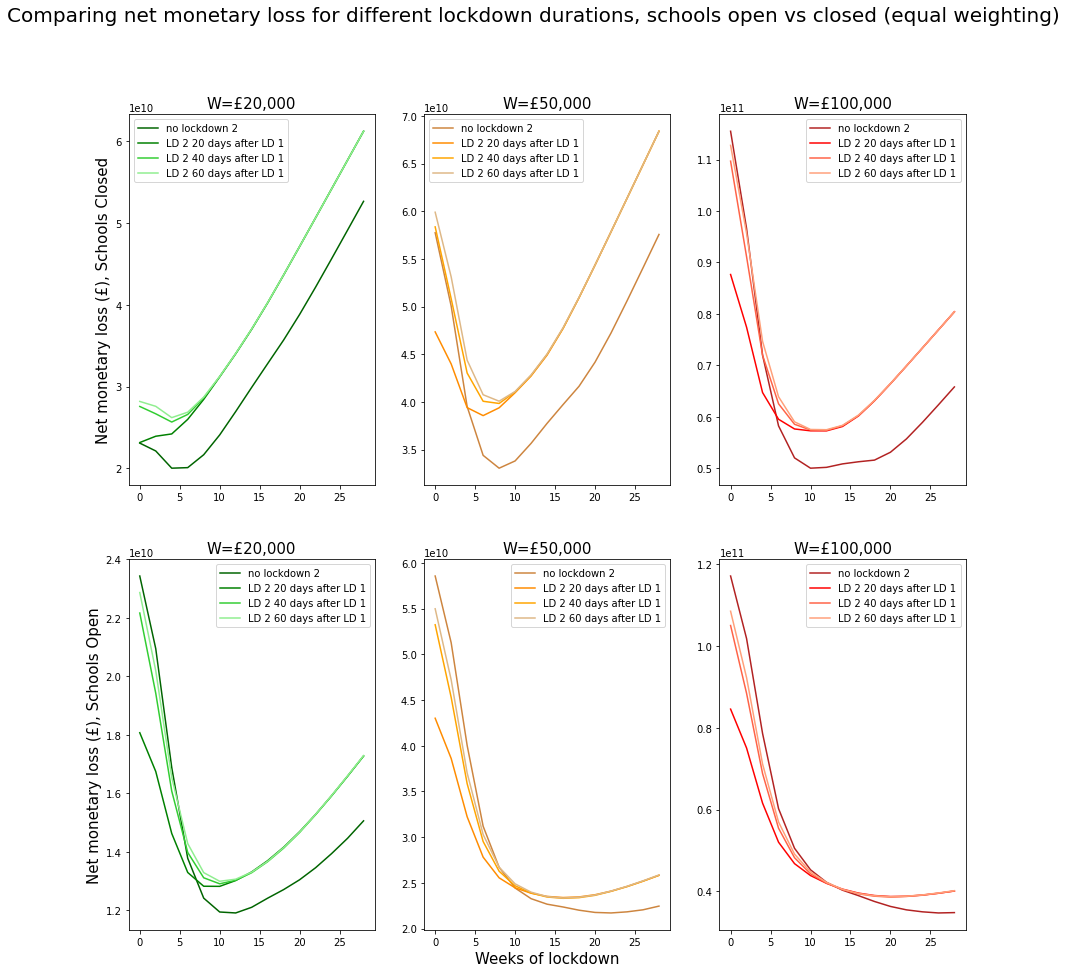

In [30]:
# Plotting:
plt.figure(figsize=(15, 15))
plt.suptitle('Comparing net monetary loss for different lockdown durations, schools open vs closed (equal weighting)', fontsize=20)


plt.subplot(231)
plt.plot(wks, costArrayLD1C[0], color = 'darkgreen', label = 'no lockdown 2')
plt.plot(wks, costArrayLD2_20DC[0], color = 'green', label = 'LD 2 20 days after LD 1')
plt.plot(wks, costArrayLD2_40DC[0], color = 'limegreen', label = 'LD 2 40 days after LD 1')
plt.plot(wks, costArrayLD2_60DC[0], color = 'lightgreen', label = 'LD 2 60 days after LD 1')
plt.ylabel('Net monetary loss (£), Schools Closed', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£20,000', fontsize = 15)

plt.subplot(232)
plt.plot(wks, costArrayLD1C[1], color = 'peru', label ='no lockdown 2')
plt.plot(wks, costArrayLD2_20DC[1], color = 'darkorange', label = 'LD 2 20 days after LD 1')
plt.plot(wks, costArrayLD2_40DC[1], color = 'orange', label = 'LD 2 40 days after LD 1')
plt.plot(wks, costArrayLD2_60DC[1], color = 'burlywood', label = 'LD 2 60 days after LD 1')
plt.legend(loc=0)
plt.title('W=£50,000', fontsize = 15)

plt.subplot(233)
plt.plot(wks, costArrayLD1C[2], color = 'firebrick', label ='no lockdown 2')
plt.plot(wks, costArrayLD2_20DC[2], color = 'red', label = 'LD 2 20 days after LD 1')
plt.plot(wks, costArrayLD2_40DC[2], color = 'tomato', label = 'LD 2 40 days after LD 1')
plt.plot(wks, costArrayLD2_60DC[2], color = 'lightsalmon', label = 'LD 2 60 days after LD 1')
plt.legend(loc=0)
plt.title('W=£100,000', fontsize = 15)

plt.subplot(234)
plt.plot(wks, costArrayLD1O[0], color = 'darkgreen', label = 'no lockdown 2')
plt.plot(wks, costArrayLD2_20DO[0], color = 'green', label = 'LD 2 20 days after LD 1')
plt.plot(wks, costArrayLD2_40DO[0], color = 'limegreen', label = 'LD 2 40 days after LD 1')
plt.plot(wks, costArrayLD2_60DO[0], color = 'lightgreen', label = 'LD 2 60 days after LD 1')
plt.ylabel('Net monetary loss (£), Schools Open', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£20,000', fontsize = 15)

plt.subplot(235)
plt.plot(wks, costArrayLD1O[1], color = 'peru', label ='no lockdown 2')
plt.plot(wks, costArrayLD2_20DO[1], color = 'darkorange', label = 'LD 2 20 days after LD 1')
plt.plot(wks, costArrayLD2_40DO[1], color = 'orange', label = 'LD 2 40 days after LD 1')
plt.plot(wks, costArrayLD2_60DO[1], color = 'burlywood', label = 'LD 2 60 days after LD 1')
plt.xlabel('Weeks of lockdown', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£50,000', fontsize = 15)

plt.subplot(236)
plt.plot(wks, costArrayLD1O[2], color = 'firebrick', label ='no lockdown 2')
plt.plot(wks, costArrayLD2_20DO[2], color = 'red', label = 'LD 2 20 days after LD 1')
plt.plot(wks, costArrayLD2_40DO[2], color = 'tomato', label = 'LD 2 40 days after LD 1')
plt.plot(wks, costArrayLD2_60DO[2], color = 'lightsalmon', label = 'LD 2 60 days after LD 1')
plt.legend(loc=0)
plt.title('W=£100,000', fontsize = 15)

plt.show()

## Triangle Plots  <a id = 'triangleplots' ><a>

In [31]:
def QALY_GDParrays(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, wks, outbreak2Start, days, schoolClosure):
    
    weekIncrement = wks[1]-wks[0]
    
    QALYarray = []
    GDParray = []
    
    if lockdown2 == True: #If there is a second lockdown:
        for i in wks:
            QALYs, GDP = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+i*7, lockdown1Start+i*7 + 40, lockdown1Start+i*7 + 68, outbreak2Start, days, schoolClosure)
            
            QALYarray.append(QALYs)
            GDParray.append(GDP)
    else: #No second lockdown:
        for i in wks:  
            QALYs, GDP = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+i*7, 0, 0, outbreak2Start, days, schoolClosure)
            
            QALYarray.append(QALYs)
            GDParray.append(GDP)
    
    return(QALYarray, GDParray)

def get_category(weeks):
    if weeks == 0:
        return 0
    if 1 <= weeks <= 5:
        return 1
    if 6 <= weeks <= 10:
        return 2
    if 11 <= weeks <= 15:
        return 3
    if 16 <= weeks <= 20:
        return 4
    else:
        return 5
    
def optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, W, wks, n, outbreak2Start, days, schoolClosure):
    QALYarray, GDParray = QALY_GDParrays(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, wks, outbreak2Start, days, schoolClosure)
    
    weekIncrement = wks[1] - wks[0]
    w1,w2,w3 = [],[],[]
    results = []
    
    for i in range(n + 1):
        for j in range(n + 1 - i):
            k = n - i - j

            v1, v2, v3 = i/n, j/n, k/n
            w1.append(v1)
            w2.append(v2)
            w3.append(v3)
            
            costArray = []
            for l in range(len(wks)):
                costArray.append(totalCost(W, QALYarray[l], GDParray[l], [v1,v2,v3]))

            optimalLockdown = costArray.index(min(costArray))*weekIncrement
            results.append(get_category(optimalLockdown))

    return(w1,w2,w3, results)

In [60]:
efficaciesArray = [0.5, 0.7, 0.9]
vaccineStart = 70
lockdown1Start = 40
lockdown2 = False  #T or F depending on if there is a second lockdown
n = 10
outbreak2Start = 366
days = 365
weekStart, weekEnd, weekIncrement = 0, 30, 2 
wks = np.arange(weekStart, weekEnd, weekIncrement)


schoolClosure = True  # Schools Closed
w11C, w21C, w31C, resultsW1C = optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 20000, wks, n, outbreak2Start, days, schoolClosure)
w12C, w22C, w32C, resultsW2C = optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 50000, wks, n, outbreak2Start, days, schoolClosure)
w13C, w23C, w33C, resultsW3C = optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 100000, wks, n, outbreak2Start, days, schoolClosure)

schoolClosure = False  # Schools Open
w11O, w21O, w31O, resultsW1O = optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 20000, wks, n, outbreak2Start, days, schoolClosure)
w12O, w22O, w32O, resultsW2O = optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 50000, wks, n, outbreak2Start, days, schoolClosure)
w13O, w23O, w33O, resultsW3O = optimalLockdownCategories(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 100000, wks, n, outbreak2Start, days, schoolClosure)

### Willingness to pay £20,000  <a id = 'W=20k' ><a>

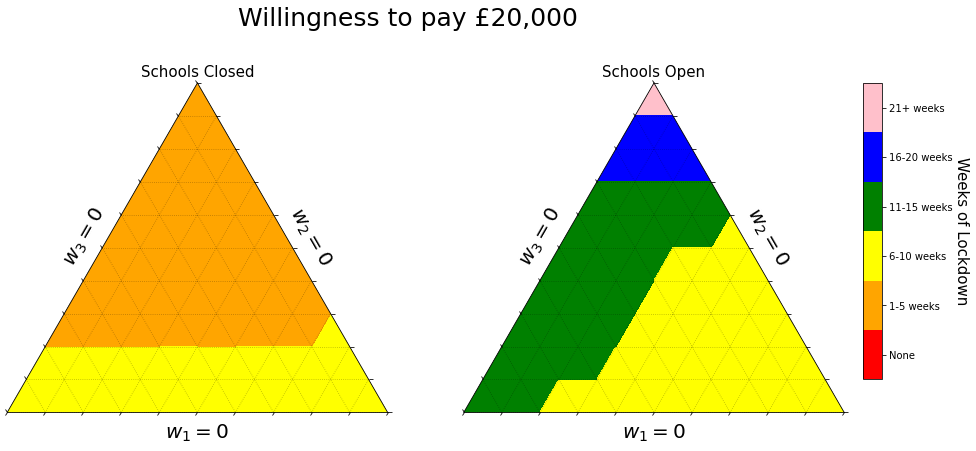

In [61]:
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'pink']
cmap = mcolors.ListedColormap(colors)
bounds = [0, 1, 2, 3, 4, 5, 6] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(15, 7))
plt.suptitle('Willingness to pay £20,000 ', fontsize = 25)

ax = fig.add_subplot(1,2,1, projection='ternary')

plot = ax.tripcolor(w11C, w21C, w31C, resultsW1C, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')
ax.set_title("Schools Closed", fontsize = 15)

ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


ax = fig.add_subplot(1,2,2, projection='ternary')

plot = ax.tripcolor(w11O, w21O, w31O, resultsW1O, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')
ax.set_title("Schools Open", fontsize = 15)

ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(plot, cax=cax, ticks=[0.5,1.5,2.5,3.5,4.5, 5.5])
colorbar.ax.set_yticklabels(['None', '1-5 weeks', '6-10 weeks', '11-15 weeks', '16-20 weeks', '21+ weeks'])
colorbar.set_label("Weeks of Lockdown", rotation=270, fontsize = 15, va="baseline")


plt.show()

### Willingness to pay £50,000  <a id = 'W=50k' ><a>

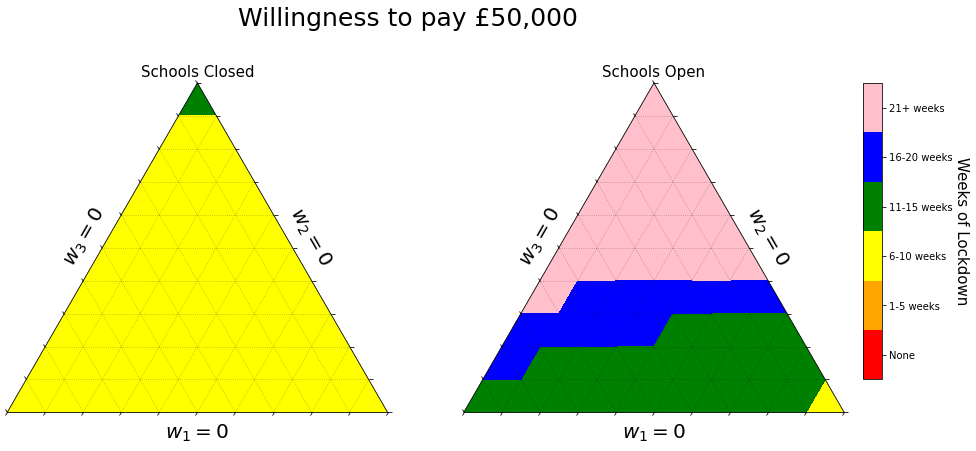

In [62]:
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'pink']
cmap = mcolors.ListedColormap(colors)
bounds = [0, 1, 2, 3, 4, 5, 6] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(15, 7))
plt.suptitle('Willingness to pay £50,000 ', fontsize = 25)

ax = fig.add_subplot(1,2,1, projection='ternary')

plot = ax.tripcolor(w12C, w22C, w32C, resultsW2C, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')
ax.set_title("Schools Closed", fontsize = 15)

ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


ax = fig.add_subplot(1,2,2, projection='ternary')

plot = ax.tripcolor(w12O, w22O, w32O, resultsW2O, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')
ax.set_title("Schools Open", fontsize = 15)

ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(plot, cax=cax, ticks=[0.5,1.5,2.5,3.5,4.5, 5.5])
colorbar.ax.set_yticklabels(['None', '1-5 weeks', '6-10 weeks', '11-15 weeks', '16-20 weeks', '21+ weeks'])
colorbar.set_label("Weeks of Lockdown", rotation=270, fontsize = 15, va="baseline")


plt.show()

### Willingness to pay £100,000  <a id = 'W=100k' ><a>

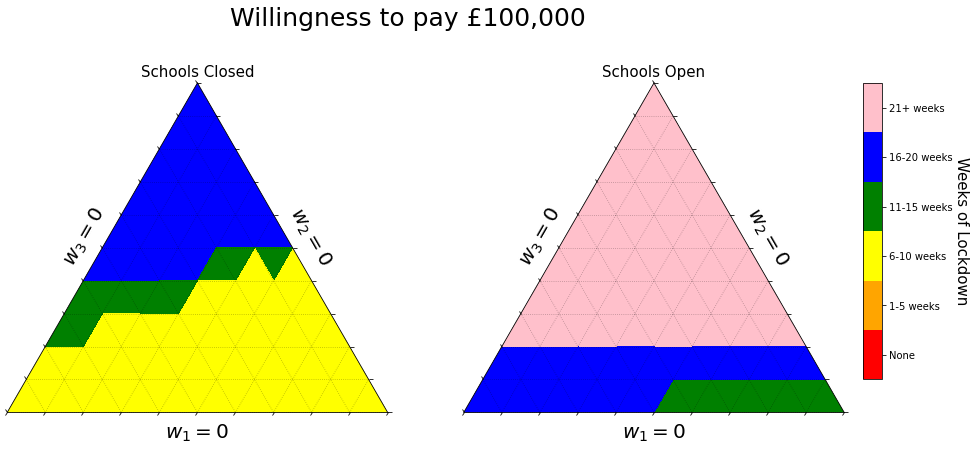

In [63]:
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'pink']
cmap = mcolors.ListedColormap(colors)
bounds = [0, 1, 2, 3, 4, 5, 6] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(15, 7))
plt.suptitle('Willingness to pay £100,000 ', fontsize = 25)

ax = fig.add_subplot(1,2,1, projection='ternary')

plot = ax.tripcolor(w13C, w23C, w33C, resultsW3C, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')
ax.set_title("Schools Closed", fontsize = 15)

ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


ax = fig.add_subplot(1,2,2, projection='ternary')

plot = ax.tripcolor(w13O, w23O, w33O, resultsW3O, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')
ax.set_title("Schools Open", fontsize = 15)

ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(plot, cax=cax, ticks=[0.5,1.5,2.5,3.5,4.5, 5.5])
colorbar.ax.set_yticklabels(['None', '1-5 weeks', '6-10 weeks', '11-15 weeks', '16-20 weeks', '21+ weeks'])
colorbar.set_label("Weeks of Lockdown", rotation=270, fontsize = 15, va="baseline")

plt.show()

### Notes on triangle plots:

As you increase the level of control $\phi$, it becomes more of a 'blanket' optimal lockdown length - I imagine because the GDP loss outweighs the QALY loss so much that it doesn't really matter how you weight them, the optimal strategy remains the same.  
Additionally, the bottom right corner (where $w_1 = w_2 = 0, w_3 = 1$) generally has the lowest number of weeks of optimal lockdown (which makes sense, as $w_3$ represents confidence in the highest efficacy 90%), whereas the top vertex is normally the highest number of weeks (high confidence in a 50% effective vaccine)  
Finally, as you increase willigness to pay - W - the length of optimal lockdown increases, as higher weight is placed on reducing deaths/hopsitalisations as opposed to GDP loss.  
At $0.58 < \phi < 0.72$, the daily GDP loss (when schools open) is very near zero/negative, meaning that the QALY loss completely dominates the plots and all the schools open plots turn pink as there is no disadvantage to just increasing the lockdown length as much as possible. So maybe avoid close to these values?

In terms of schools open vs closed, the main change is to the GDP. Closing schools essentially just adds more GDP loss than if you leave them open - which is shown in the triangle plots as the optimal lockdown length is shorter at every weighting, as it just costs way too much to have a long period of lockdown and schools closed. so this behaves as expected.